<a href="https://colab.research.google.com/github/kukuhagushermawan/CVL_Assignment01/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment01 CVL**

**Nama:** Kukuh Agus Hermawan   
**NIM:** 24/533395/PA/22573  
**Kelas:** KOM  

# **Implementasi Image Enhancement pada Berbagai Kondisi Citra**

Tugas ini mengimplementasikan metode Image Enhancement untuk meningkatkan kualitas citra. Metode enhancement diterapkan pada beberapa kondisi citra seperti low contrast, high contrast, underexposure, overexposure, distribusi intensitas yang tidak seimbang, blur, noise, over-sharpened, dan low resolution.

# **Image Enhancement**

Image enhancement atau peningkatan kualitas citra bertujuan untuk memperbaiki kualitas gambar agar informasi pada citra lebih mudah dianalisis dan hasil lebih akurat. Proses enhancement tidak wajib dilakukan jika kualitas citra sudah baik.  

Kualitas citra dibedakan menjadi dua, yaitu spasial dan non spasial.  


## 1. Spasial Enhancement
Spasial enhancement: memodifikasi nilai piksel berdasarkan tetangganya. Metode yang digunakan disebut filtering based enhancement.  

Permasalahan spasial:
1. Blur: sharpening filter (misalnya laplacian).  
2. Noise: smoothing/averaging filter (mean, gaussian, median).  
3. Terlalu tajam: smoothing filter (misalnya gaussian).  
4. Low Resolution: upsampling (nearest neighbor, bilinear, bicubic).


## Metode Filtering Based Enhancement

Metode ini mengganti nilai piksel dengan kombinasi tetangganya menggunakan kernel atau mask tertentu.  
Pendekatan ini termasuk ke dalam kategori one simple filtering.

Filter dapat dibedakan menjadi dua jenis:  
- **Linear filter**: operasi menggunakan perhitungan linear (konvolusi) dengan kernel. Contoh: mean filter, Gaussian filter, sharpening filter (Laplacian).  
- **Non linear filter**: operasi tidak berdasarkan konvolusi linear, tetapi metode lain. Contoh: median filter yang mengganti nilai piksel dengan median tetangganya.  

Beberapa contoh filter:  
- **Mean filter**:  smoothing.  
- **Gaussian filter**: smoothing dengan hasil lebih halus.  
- **Median filter**: menghilangkan noise.  
- **Sharpening filter** (misalnya laplacian): meningkatkan detail atau ketajaman tepi.      


## 2. Non Spasial Enhancement
Non spasial enhancement: memodifikasi nilai piksel secara individu. Metode yang digunakan disebut pixel based enhancement.  

Permasalahan non spasial:
1. Underexposure (gambar terlalu gelap).  
2. Overexposure (gambar terlalu terang).  
3. Low contrast (kontras rendah).  
4. Distribusi warna tidak balance.  


## Metode Pixel Based Enhancement

1. **Contrast Stretching**  
   Digunakan untuk memperlebar rentang intensitas citra, sehingga perbedaan antara piksel terang dan gelap lebih jelas.

2. **Transformation**  
   Meliputi image negative, log transform, inverse log transform, dan piecewise linear transform. Metode ini mengubah nilai piksel ke nilai baru dengan fungsi tertentu.  

3. **Histogram Equalization**  
   Digunakan untuk menyeimbangkan distribusi histogram agar kontras lebih merata. Biasanya digunakan untuk citra gelap, terang, atau low contrast.  



# **Pixel Based Enhancement**


## **1. Metode Contrast Stretching**

Kontras menyatakan sebaran terang (lightness) dan gelap (darkness) di dalam sebuah gambar. Citra dapat dikelompokkan ke dalam tiga kategori kontras: citra kontras-rendah (low contrast), citra kontras bagus (normal contrast), dan citra kontras-tinggi (high contrast).

### Perbaikan kontras
Citra dengan kontras rendah dapat diperbaiki kualitasnya dengan contrast stretching. Melalui operasi ini, nilai keabuan pixel akan direntangkan dari 0 sampai 255 (pada citra 8-bit), sehingga seluruh nilai keabuan pixel terpakai secara merata.


## low contrast [terang]

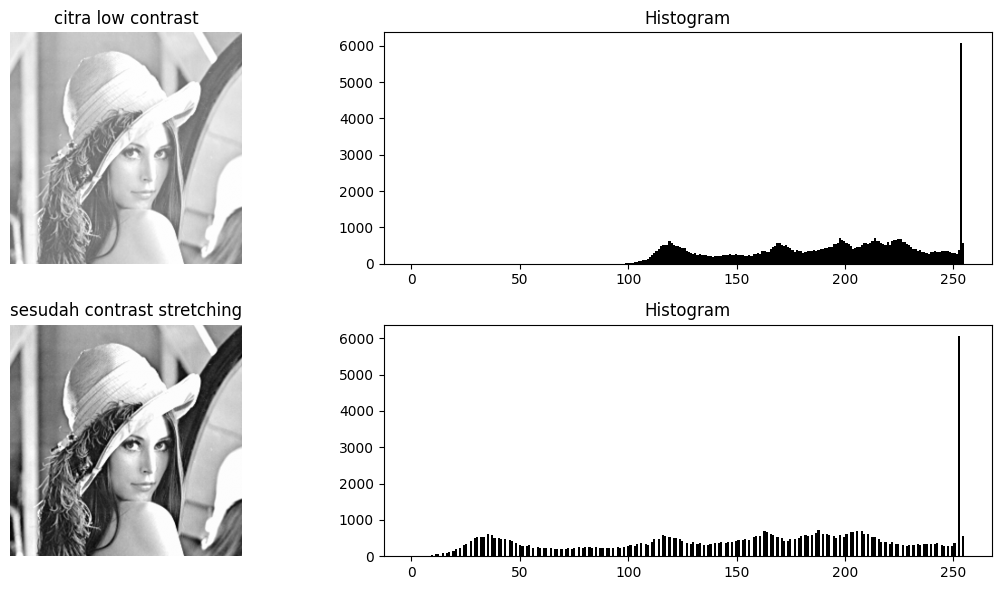

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/low_contrast"

resp = urllib.request.urlopen(url)
buf  = np.asarray(bytearray(resp.read()), dtype=np.uint8)
imgc = cv2.imdecode(buf, cv2.IMREAD_COLOR)
image = cv2.cvtColor(imgc, cv2.COLOR_BGR2GRAY)

h, w = 256, 256
image = cv2.resize(image, (w, h))

# contrast stretching
a, b = 0, 255
output = np.zeros((h, w), dtype=np.uint8)
sourceMin = image.min()
sourceMax = image.max()

for i in range(h):
    for j in range(w):
        output[i, j] = (image[i, j] - sourceMin) * ((b - a) / (sourceMax - sourceMin)) + a

# output dan histogram
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("citra low contrast")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(image.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(2,2,3)
plt.imshow(output, cmap='gray', vmin=0, vmax=255)
plt.title("sesudah contrast stretching")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(output.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()


### Analisis hasil contrast stretching (low contrast)

- Sebelum: gambar dominan terang, histogram menumpuk di area kanan mendekati 255 sehingga detail area gelap kurang terlihat.  

- Sesudah: setelah contrast stretching, histogram melebar dari 0 hingga 255 sehingga distribusi piksel lebih merata, detail area gelap maupun terang lebih jelas.  

- Kesimpulan: contrast stretching membuat citra low contrast menjadi lebih seimbang (kontras balance), sehingga objek lebih tajam dan mudah dibedakan.  


## high contrast

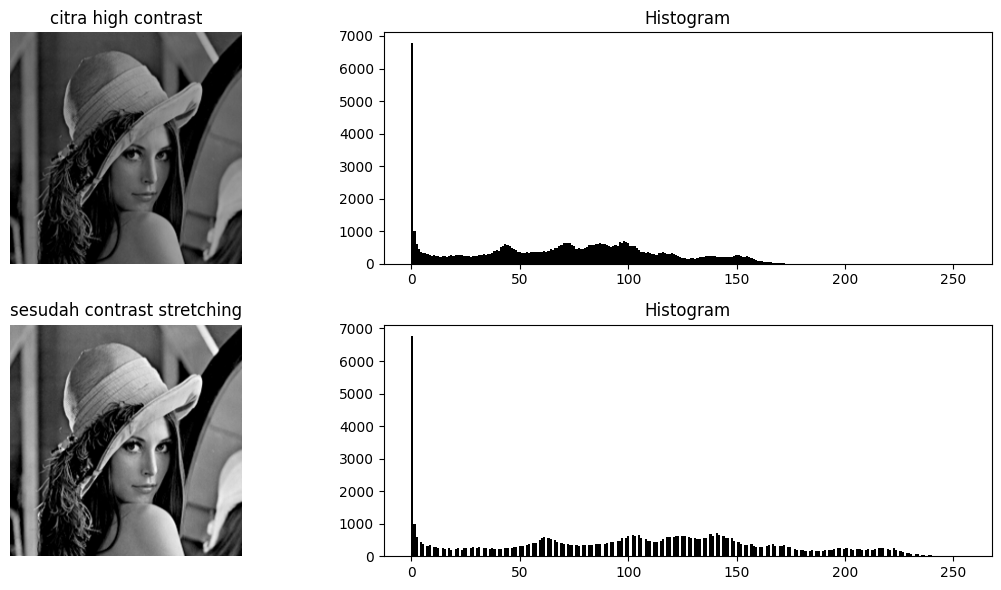

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/high-contrast"

resp = urllib.request.urlopen(url)
buf  = np.asarray(bytearray(resp.read()), dtype=np.uint8)
imgc = cv2.imdecode(buf, cv2.IMREAD_COLOR)
image = cv2.cvtColor(imgc, cv2.COLOR_BGR2GRAY)

h, w = 256, 256
image = cv2.resize(image, (w, h))

# contrast stretching
a, b = 0, 255
output = np.zeros((h, w), dtype=np.uint8)
sourceMin = image.min()
sourceMax = image.max()

for i in range(h):
    for j in range(w):
        output[i, j] = (image[i, j] - sourceMin) * ((b - a) / (sourceMax - sourceMin)) + a

# output dan histogram
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("citra high contrast")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(image.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(2,2,3)
plt.imshow(output, cmap='gray', vmin=0, vmax=255)
plt.title("sesudah contrast stretching")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(output.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()


### Analisis hasil contrast stretching (high contrast)

- Sebelum: citra dominan gelap, histogram menumpuk di area tertentu sehingga detail pada area terang kurang terlihat.  

- Sesudah: setelah contrast stretching, histogram melebar hingga mendekati 0–255 sehingga distribusi piksel lebih merata, detail pada area gelap maupun terang lebih jelas.  

- Kesimpulan: contrast stretching membuat citra high contrast menjadi lebih seimbang (kontras balance), sehingga perbedaan antar objek lebih mudah dibedakan.  


## **2. Transformation**

## Underexposure/gambar terlalu gelap
Metode Transformation [log transform]

#### Log transform
1. Untuk nilai keabuan rendah (gelap)  
   dipetakan ke rentang yang lebih luas. Hasilnya, detail yang tersembunyi di area gelap lebih terlihat.  

2. Untuk nilai keabuan tinggi (terang)
   dipetakan ke rentang yang lebih sempit. Hasilnya, bagian terang tidak terlalu cerah.  

log transform cocok digunakan untuk memperbaiki citra yang underexposure(terlalu gelap).  

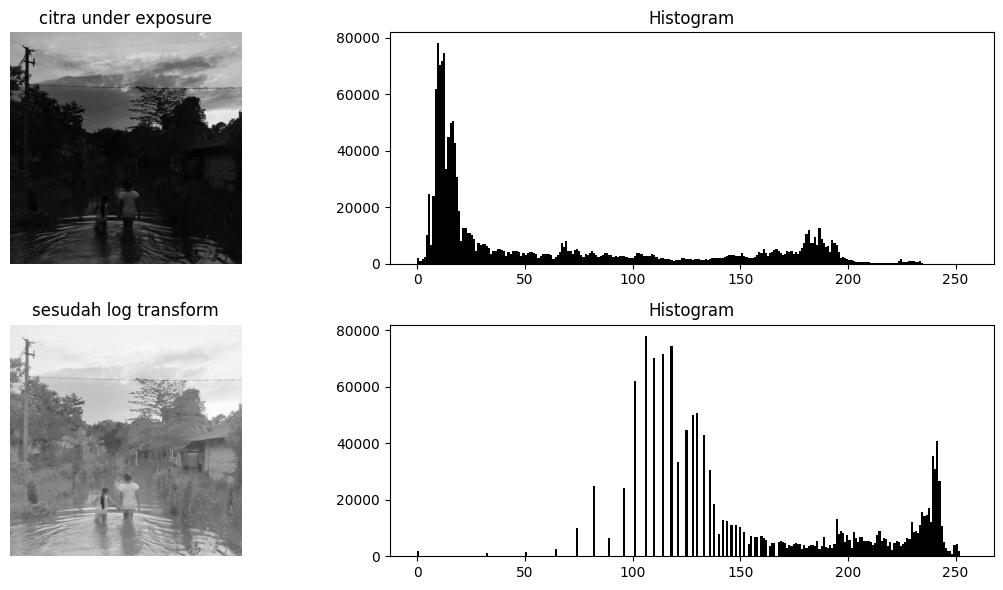

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/kukuhagushermawan/image-enhancement/main/images/underexposure_image.png"

resp = urllib.request.urlopen(url)
buf = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)

# log transform
c = 255 / np.log(1 + np.max(image))
log_transformed = c * np.log(1 + image.astype(np.float32))
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

# output dan histogram
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("citra under exposure")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(image.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(2,2,3)
plt.imshow(log_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("sesudah log transform")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(log_transformed.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()


### **Analisis hasil log transform**

- Sebelum: gambar dominan gelap, histogram menumpuk di kiri sehingga detail area gelap hilang, bagian terang kurang jelas.  

- Sesudah: setelah log transform, histogram bergeser dan melebar ke tengah sehingga area gelap menjadi lebih terang, detail lebih terlihat, kontras citra meningkat.  

- Kesimpulan: log transform membuat citra underexposure (terlalu gelap) menjadi lebih jelas dengan menonjolkan detail pada area gelap.  


## Overexposure / gambar terlalu terang  
**Metode: Inverse log transform**

1. Untuk nilai keabuan tinggi (terang) dapat ditekan, sehingga detail di area terang bisa terlihat.  
2. Untuk nilai keabuan rendah (gelap) hasilnya relatif tetap, tidak banyak berubah.  

Inverse log transform cocok untuk memperbaiki gambar yang terlalu terang (overexposure).  

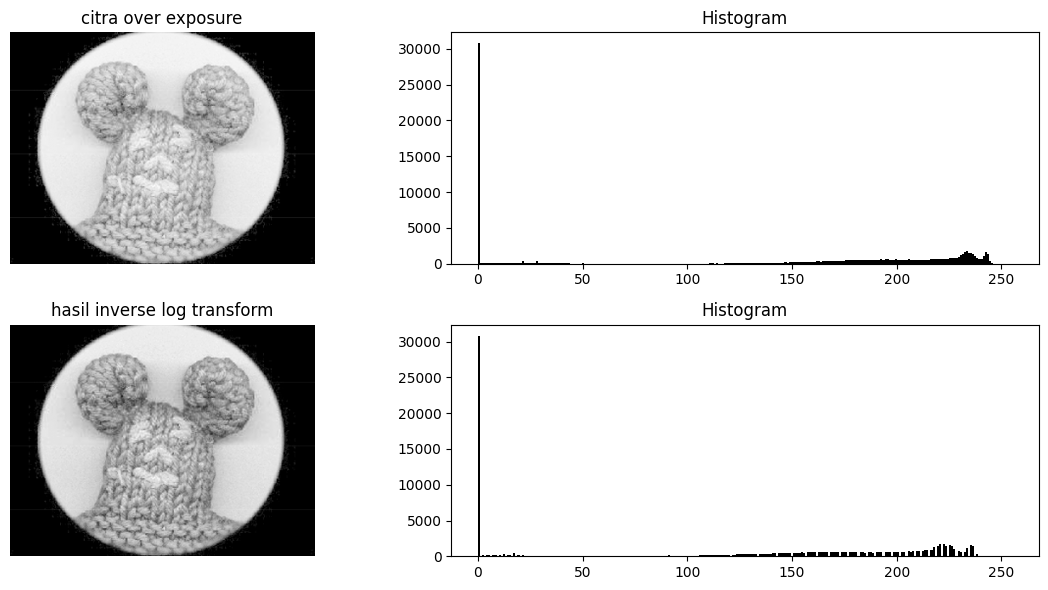

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/over%20exposure"

resp = urllib.request.urlopen(url)
buf = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)

norm_img = image / 255.0

# inverse log transform: s = c * (exp(r) - 1)
c = 255 / (np.exp(1) - 1)
inv_log = c * (np.exp(norm_img) - 1)
inv_log = np.clip(inv_log, 0, 255).astype(np.uint8)

# output dan histogram
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("citra over exposure")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(image.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(2,2,3)
plt.imshow(inv_log, cmap='gray', vmin=0, vmax=255)
plt.title("hasil inverse log transform")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(inv_log.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()

### Analisis hasil inverse log transform

- Sebelum: citra dominan terang (overexposure), histogram menumpuk di area kanan sehingga detail pada bagian terang hilang dan sulit dibedakan.  

- Sesudah: setelah inverse log transform, histogram menyebar ke arah kiri sehingga area terang ditekan sehingga detail pada bagian terang lebih terlihat, sedangkan area gelap relatif tidak banyak berubah.  

- Kesimpulan: inverse log transform membuat citra overexposure (terlalu terang) menjadi lebih seimbang dengan menekan intensitas tinggi, sehingga detail pada area terang lebih jelas.  


## **3. Histogram Equalization**
**Masalah pada image: distribusi tidak balance**

Tujuan dilakukannya histogram equalization:
- Untuk memperoleh penyebaran histogram yang merata, sehingga setiap derajat keabuan memiliki jumlah pixel yang relatif sama.  
- Memperlebar rentang nilai keabuan, sehingga dapat meningkatkan kekontrasan citra.  


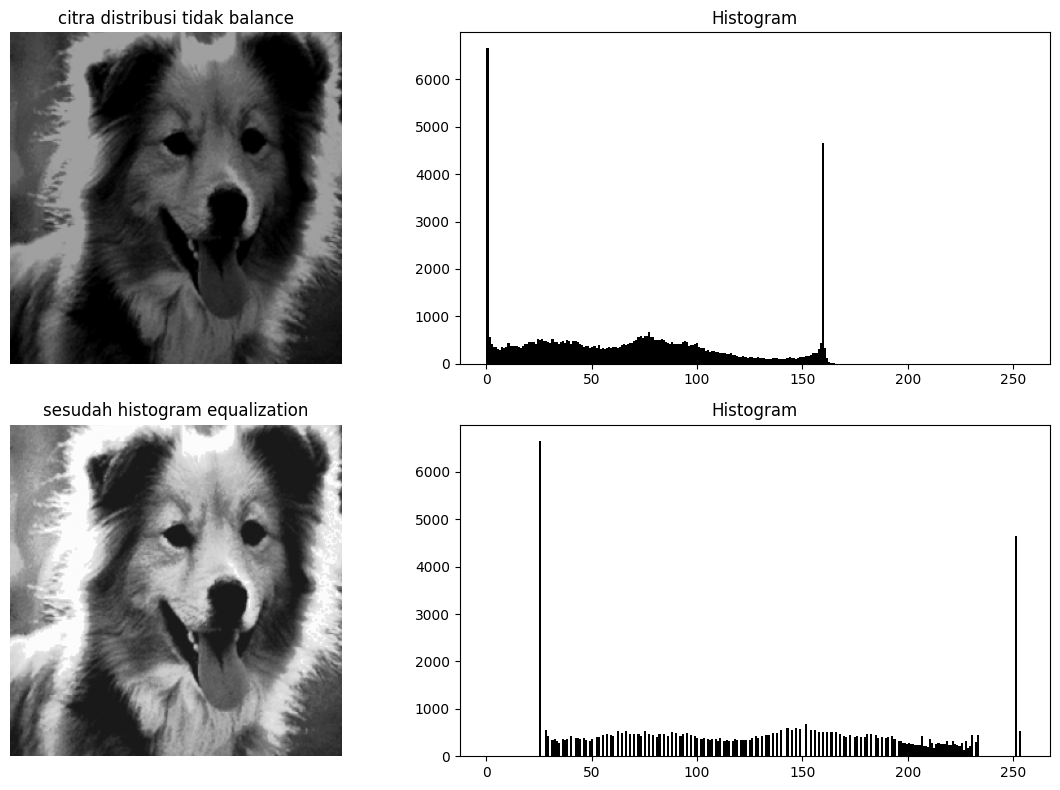

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/image-histo"

resp = urllib.request.urlopen(url)
buf = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (256, 256))

# hitung histogram, PDF, dan CDF
L = 256
h, w = img.shape
N = h * w

# histogram (n_k) untuk k=0..255
hist = np.bincount(img.ravel(), minlength=L)

# PDF p_r(r_k) = n_k / N
pdf = hist.astype(np.float64) / N

# CDF s_k = sum_{i=0..k} p_r(r_i)
cdf = np.cumsum(pdf)

# mapping: s = T(r) = (L-1) * CDF(r)
mapping = np.floor((L - 1) * cdf).astype(np.uint8)

# equalization: g(x,y) = mapping[f(x,y)]
equalized = mapping[img]

# output dan histogram
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("citra distribusi tidak balance")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(img.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(2,2,3)
plt.imshow(equalized, cmap='gray', vmin=0, vmax=255)
plt.title("sesudah histogram equalization")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()


### Analisis hasil histogram equalization

- Sebelum: histogram tidak balance, hanya menumpuk di area tertentu sehingga distribusi keabuan tidak seimbang, kontras citra rendah.  
- Sesudah: histogram lebih rata dan tersebar ke seluruh rentang keabuan sehingga kontras citra meningkat, detail lebih jelas.  
- Kesimpulan: histogram equalization memperbaiki citra dengan distribusi intensitas yang lebih seimbang, sehingga objek lebih mudah dibedakan.  


# **Filter Based Enhancement**


### **1. Sharpening Filter -> Laplacian Filter**
### Blur (menangani citra buram dengan menajamkan tepi menggunakan laplace dan sharpening)

Blur adalah kondisi ketika citra terlihat buram karena detail tepinya tidak jelas. Untuk mengatasi hal ini, digunakan laplace dan sharpening.  Laplace dihitung melalui turunan kedua dari citra untuk mendeteksi perubahan intensitas yang tajam, sehingga bagian tepi (edge) yang semula samar akibat blur akan lebih jelas.

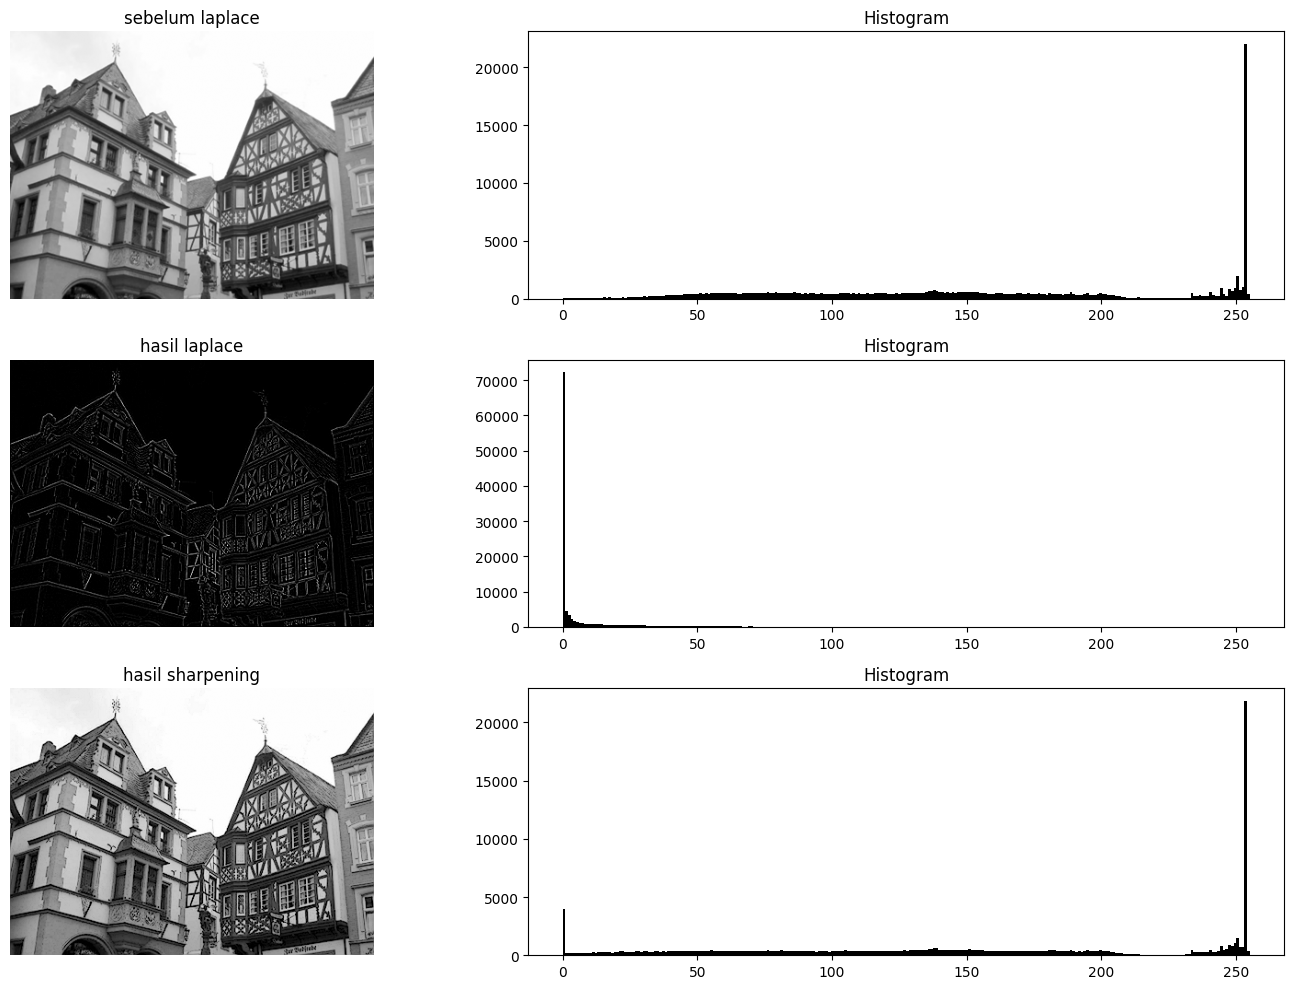

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/huose_laplace"

resp = urllib.request.urlopen(url)
buf = np.asarray(bytearray(resp.read()), dtype=np.uint8)
imgc = cv2.imdecode(buf, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(imgc, cv2.COLOR_BGR2GRAY)

# kernel laplacian
laplace_kernel = np.array([[0, 1, 0],
                           [1, -4, 1],
                           [0, 1, 0]], dtype=np.float32)

# konvolusi
h, w = gray.shape
pad = 1
padded = np.pad(gray, pad, mode='constant', constant_values=0)
output = np.zeros_like(gray, dtype=np.float32)

for i in range(h):
    for j in range(w):
        region = padded[i:i+3, j:j+3]
        output[i, j] = np.sum(region * laplace_kernel)

output = np.clip(output, 0, 255).astype(np.uint8)

# sharpening (mengurangkan citra awal/gray dengan citra hasil dari laplace)
k = 1.0
sharpened = cv2.addWeighted(gray, 1.0, output, -k, 0)
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

# output dan histogram
plt.figure(figsize=(15,10))

plt.subplot(3,2,1)
plt.imshow(gray, cmap='gray')
plt.title("sebelum laplace")
plt.axis('off')

plt.subplot(3,2,2)
plt.hist(gray.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(3,2,3)
plt.imshow(output, cmap='gray')
plt.title("hasil laplace")
plt.axis('off')

plt.subplot(3,2,4)
plt.hist(output.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(3,2,5)
plt.imshow(sharpened, cmap='gray')
plt.title("hasil sharpening")
plt.axis('off')

plt.subplot(3,2,6)
plt.hist(sharpened.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()


### Analisis hasil laplacian filter

- Sebelum: citra terlihat masih buram, detail tepi tidak begitu jelas. Histogram menunjukkan distribusi piksel menyebar pada area intensitas tinggi.

- Sesudah: tepi objek menjadi lebih jelas. Histogram didominasi intensitas rendah (hitam) karena hasil deteksi tepi menghasilkan banyak area gelap dengan garis tepi yang tajam.

- Kesimpulan: laplacian hanya menajamkan tepi citra. Maka akan dilakukan sharpening yaitu dengan cara mengurangi citra awal (gray scale) dengan hasil dari laplace sehingga akan dihasilkan citra yang lebih hd dan detail tepi juga jelas.


### **2. Smoothing Filter -> Median Filter**
### Noise

image smoothing bertujuan untuk menghasilkan efek blur dan sekaligus mengurangi derau (noise) pada citra.  

- Derau pada citra umumnya berupa variasi intensitas suatu pixel yang tidak berkorelasi dengan pixel-pixel tetangganya.  
- Pixel yang mengalami gangguan biasanya memiliki frekuensi tinggi.  
- Komponen citra berfrekuensi rendah cenderung memiliki pixel bernilai konstan atau berubah sangat lambat.  

imagwe smoothing dilakukan untuk menekan komponen berfrekuensi tinggi dan meloloskan komponen berfrekuensi rendah.  
Cara yang digunakan adalah mengganti nilai sebuah pixel dengan nilai rata-rata dari pixel tersebut beserta pixel-pixel tetangganya.


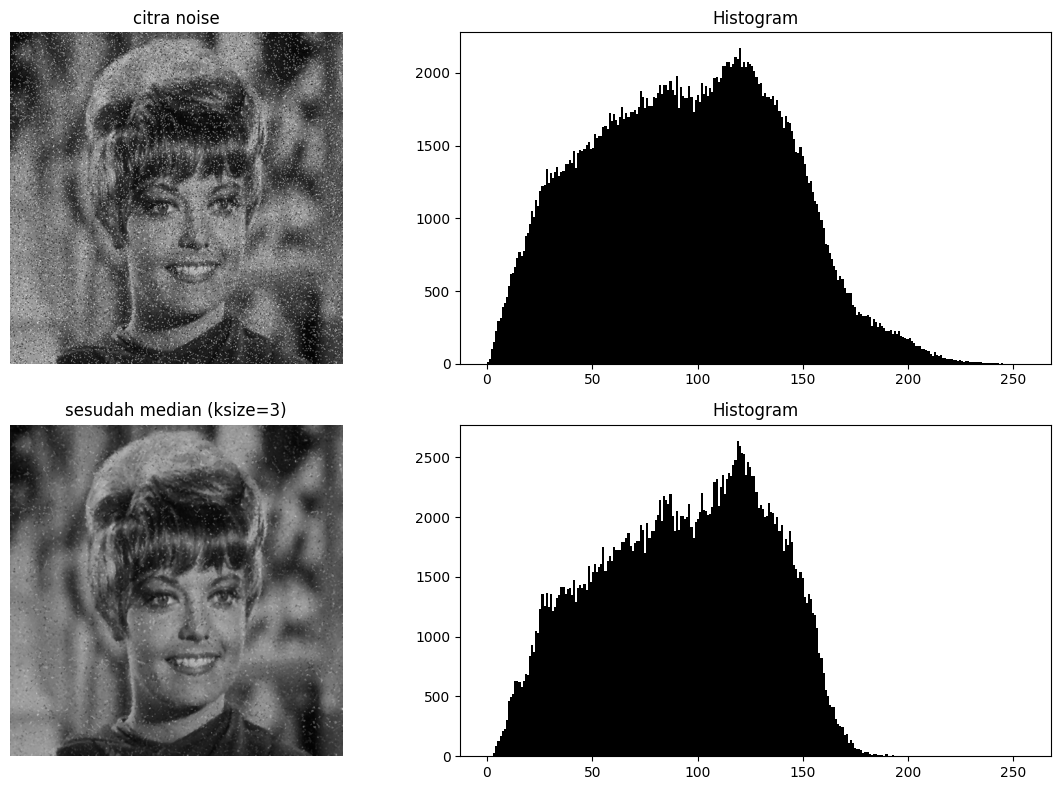

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/noise"
resp = urllib.request.urlopen(url)
buf  = np.asarray(bytearray(resp.read()), dtype=np.uint8)
imgc = cv2.imdecode(buf, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(imgc, cv2.COLOR_BGR2GRAY)

h, w = gray.shape
scale = min(512/h, 512/w, 1.0)
if scale < 1.0:
    gray = cv2.resize(gray, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)

# median filter
def median_filter(img, ksize=3, padding_mode='reflect'):
    """
    img: 2D array (grayscale, uint8)
    ksize: ukuran jendela ganjil (3,5,7,...)
    padding_mode: 'reflect' | 'constant' | 'edge'
    """
    assert ksize % 2 == 1, "ksize harus ganjil"
    r = ksize // 2

    if padding_mode == 'reflect':
        pad_img = np.pad(img, ((r, r), (r, r)), mode='reflect')
    elif padding_mode == 'edge':
        pad_img = np.pad(img, ((r, r), (r, r)), mode='edge')
    else:
        pad_img = np.pad(img, ((r, r), (r, r)), mode='constant', constant_values=0)

    out = np.zeros_like(img)
    H, W = img.shape
    for i in range(H):
        for j in range(W):
            window = pad_img[i:i+ksize, j:j+ksize].ravel()
            out[i, j] = np.median(window)
    return out

# ksize
median3 = median_filter(gray, ksize=3, padding_mode='reflect')

# output dan histogram
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title("citra noise")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(gray.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.subplot(2,2,3)
plt.imshow(median3, cmap='gray', vmin=0, vmax=255)
plt.title("sesudah median (ksize=3)")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(median3.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram")

plt.tight_layout()
plt.show()


### Analisis hasil median filter

- Sebelum: citra banyak noisenya sehingga detail wajah tampak kabur. Histogram menyebar tidak rata.

- Sesudah: setelah median filter, noise berkurang signifikan. Histogram terlihat lebih stabil dengan distribusi lebih halus, sehingga detail objek lebih jelas.  

- Kesimpulan: median filter efektif untuk mengurangi noise pada citra, karena mengganti nilai pixel dengan median dari tetangganya sehingga noise di gambar dapat dihilangkan tanpa mengurangi detail yang penting.  


### **3. Smoothing Filter -> Gaussian Filter**  
**Masalah pada image: Terlalu tajam (over sharpened)**  

Gaussian smoothing digunakan untuk smoothing citra yang terlalu tajam dengan cara memberikan efek blur.  
Metode ini bekerja dengan memberikan bobot pada piksel tetangga berdasarkan fungsi gaussian, di mana piksel yang lebih dekat dengan pusat memiliki bobot lebih besar dibandingkan yang lebih jauh.  

- Parameter σ (sigma) menentukan tingkat kelembutan:  
  - Semakin kecil σ maka hasil smoothing ringan (detail masih terlihat).  
  - Semakin besar σ maka hasil smoothing kuat (citra makin halus/blur).  

Dengan gaussian filter didapat citra yang lebih natural dan tidak terlalu hd.  



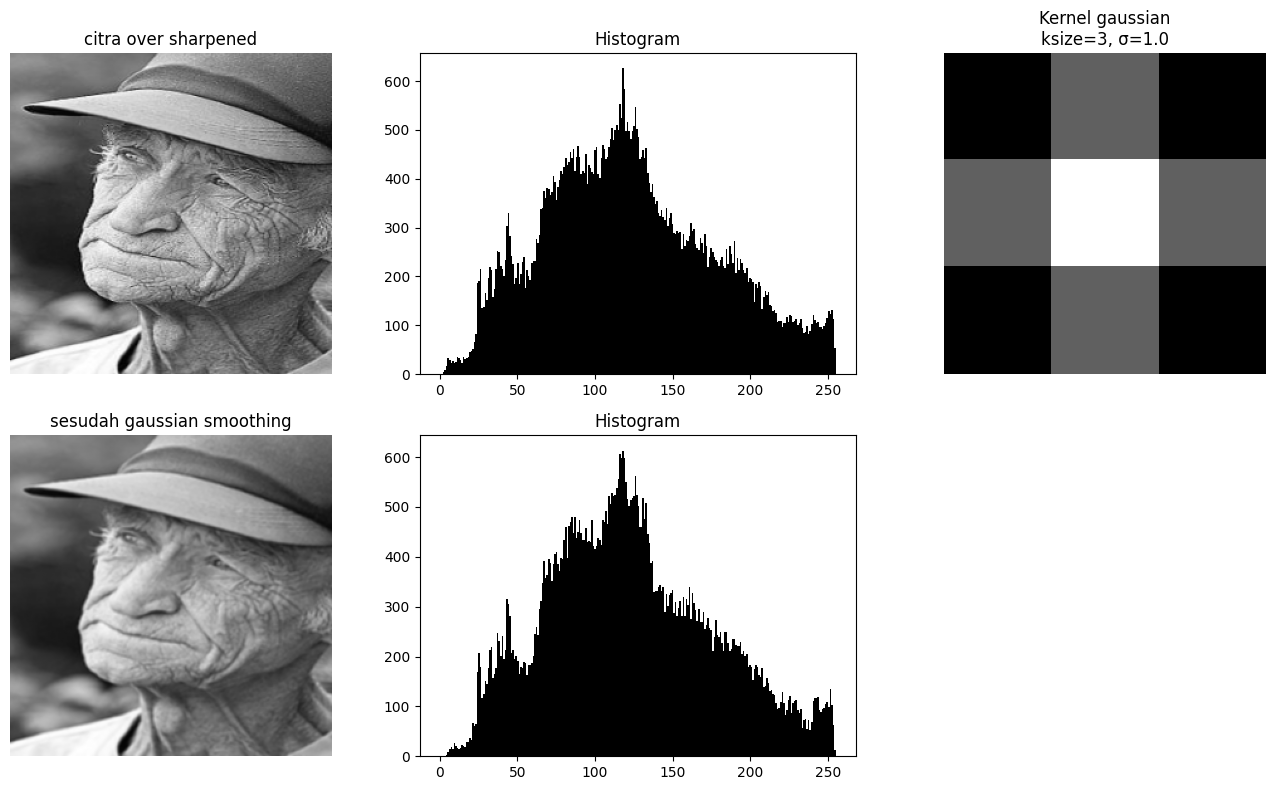

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/overSharpened"
resp = urllib.request.urlopen(url)
buf  = np.asarray(bytearray(resp.read()), dtype=np.uint8)
imgc = cv2.imdecode(buf, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(imgc, cv2.COLOR_BGR2GRAY)
gray = cv2.resize(gray, (256, 256))

# kernel gaussian
def gaussian_kernel(ksize=7, sigma=1.5):
    ax = np.arange(-(ksize//2), ksize//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = (1/(2*np.pi*sigma**2)) * np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    kernel /= kernel.sum()
    return kernel

ksize, sigma = 3, 1.0
K = gaussian_kernel(ksize, sigma)

# konvolusi
smoothed = cv2.filter2D(gray, ddepth=-1, kernel=K, borderType=cv2.BORDER_REFLECT)

# output dan histogram
plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title('citra over sharpened')
plt.axis('off')

plt.subplot(2,3,2)
plt.hist(gray.ravel(), bins=256, range=(0,255), color='black')
plt.title('Histogram')

plt.subplot(2,3,3)
plt.imshow(K, cmap='gray')
plt.title(f'Kernel gaussian\nksize={ksize}, σ={sigma}')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(smoothed, cmap='gray', vmin=0, vmax=255)
plt.title('sesudah gaussian smoothing')
plt.axis('off')

plt.subplot(2,3,5)
plt.hist(smoothed.ravel(), bins=256, range=(0,255), color='black')
plt.title('Histogram')

plt.tight_layout()
plt.show()


### Analisis hasil gaussian smoothing

- Sebelum: citra terlihat terlalu tajam, detail halus (kerutan wajah/topi) sangat menonjol. Histogram menyebar luas, menandakan kontras tinggi.  

- Sesudah: setelah gaussian smoothing, citra menjadi lebih halus, detail halus tidak terlalu menonjol. Histogram tetap menyebar, tetapi distribusinya lebih merata.  

- Kesimpulan: gaussian filter berhasil mengurangi ketajaman berlebih pada citra (over sharpened), sehingga citra tampak lebih natural.

### **4. Upsampling -> Bicubic**  
**Masalah pada image: Low resolution**  

Bicubic interpolation digunakan untuk memperbesar citra yang memiliki jumlah piksel sedikit (low resolution) sehingga detail gambar kurang jelas. Metode ini menghitung nilai piksel baru dengan melihat 16 piksel di sekitarnya (4×4 area) sehingga hasil gambar menjadi lebih smooth.

- Parameter ratio digunakan untuk menentukan faktor pembesaran citra.
- Parameter a (biasanya −0.5) digunakan untuk menghitung bobot piksel pada proses interpolasi.

Dengan metode bicubic, citra yang memiliki resolusi rendah dapat diperbesar sehingga tampilannya lebih smooth dan natural.  



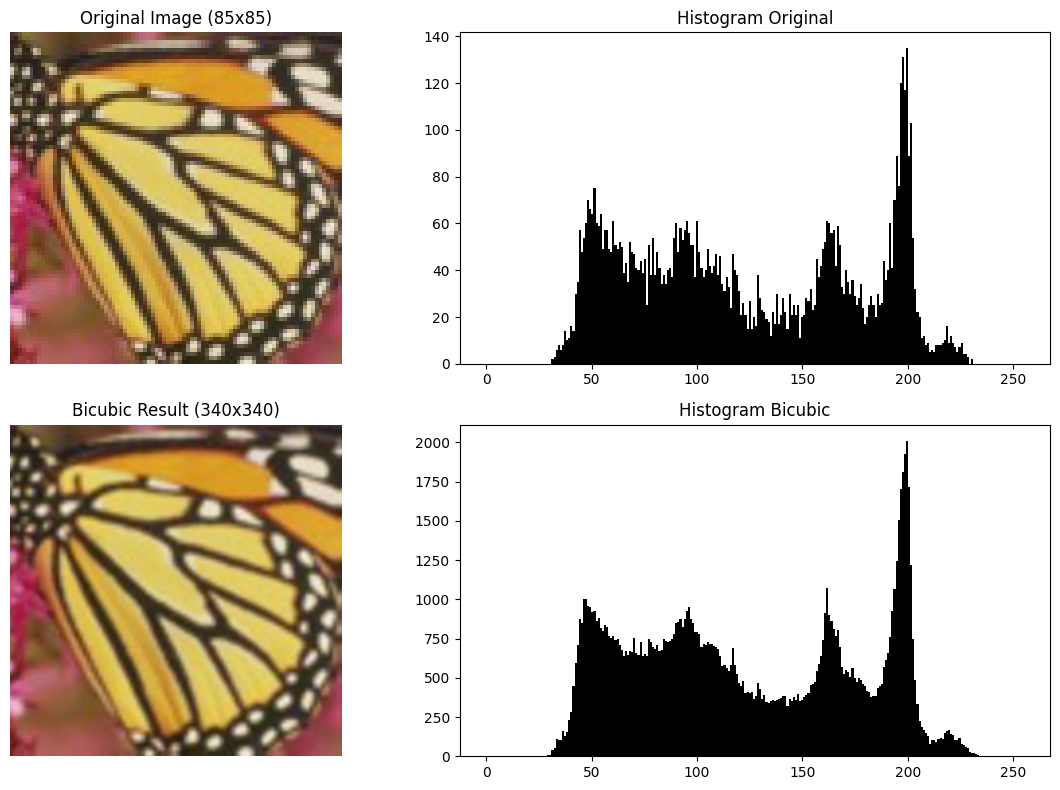

In [ ]:
import cv2
import numpy as np
import math
import urllib.request
import matplotlib.pyplot as plt

url = "https://github.com/kukuhagushermawan/image-enhancement/raw/refs/heads/main/images/lowreskupu.png"

resp = urllib.request.urlopen(url)
buf = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv2.imdecode(buf, cv2.IMREAD_COLOR)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

H, W, C = img.shape


# bicubic kernel
def u(s, a):

    s = abs(s)

    if s <= 1:
        return (a+2)*(s**3) - (a+3)*(s**2) + 1

    elif s <= 2:
        return a*(s**3) - 5*a*(s**2) + 8*a*s - 4*a

    return 0


# padding image
def padding(img, H, W, C):

    zimg = np.zeros((H+4, W+4, C), dtype=img.dtype)

    zimg[2:H+2,2:W+2,:] = img

    zimg[2:H+2,0:2,:] = img[:,0:1,:]
    zimg[2:H+2,W+2:W+4,:] = img[:,W-1:W,:]

    zimg[0:2,2:W+2,:] = img[0:1,:,:]
    zimg[H+2:H+4,2:W+2,:] = img[H-1:H,:,:]

    zimg[0:2,0:2,:] = img[0,0,:]
    zimg[H+2:H+4,0:2,:] = img[H-1,0,:]

    zimg[0:2,W+2:W+4,:] = img[0,W-1,:]
    zimg[H+2:H+4,W+2:W+4,:] = img[H-1,W-1,:]

    return zimg


# bicubic interpolation
def bicubic(img, ratio, a):

    H, W, C = img.shape

    img = padding(img, H, W, C)

    dH = int(H * ratio)
    dW = int(W * ratio)

    dst = np.zeros((dH, dW, C), dtype=np.float32)

    h = 1 / ratio

    for c in range(C):
        for j in range(dH):
            for i in range(dW):

                x = i*h + 2
                y = j*h + 2

                x1 = 1 + x - math.floor(x)
                x2 = x - math.floor(x)
                x3 = math.floor(x) + 1 - x
                x4 = math.floor(x) + 2 - x

                y1 = 1 + y - math.floor(y)
                y2 = y - math.floor(y)
                y3 = math.floor(y) + 1 - y
                y4 = math.floor(y) + 2 - y


                mat_l = np.array([[u(x1,a), u(x2,a), u(x3,a), u(x4,a)]], dtype=np.float32)

                mat_m = np.array([
                    [img[int(y-y1),int(x-x1),c],img[int(y-y2),int(x-x1),c],img[int(y+y3),int(x-x1),c],img[int(y+y4),int(x-x1),c]],
                    [img[int(y-y1),int(x-x2),c],img[int(y-y2),int(x-x2),c],img[int(y+y3),int(x-x2),c],img[int(y+y4),int(x-x2),c]],
                    [img[int(y-y1),int(x+x3),c],img[int(y-y2),int(x+x3),c],img[int(y+y3),int(x+x3),c],img[int(y+y4),int(x+x3),c]],
                    [img[int(y-y1),int(x+x4),c],img[int(y-y2),int(x+x4),c],img[int(y+y3),int(x+x4),c],img[int(y+y4),int(x+x4),c]]
                ], dtype=np.float32)

                mat_r = np.array([[u(y1,a)],[u(y2,a)],[u(y3,a)],[u(y4,a)]], dtype=np.float32)

                value = np.dot(np.dot(mat_l, mat_m), mat_r).item()

                dst[j, i, c] = value

    return np.clip(dst,0,255).astype(np.uint8)


# parameter
ratio = 4
a = -0.5

dst = bicubic(img, ratio, a)

H2, W2, C2 = dst.shape


# histogram
gray_original = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray_bicubic = cv2.cvtColor(dst, cv2.COLOR_RGB2GRAY)


# visualization
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title(f"Original Image ({H}x{W})")
plt.axis("off")

plt.subplot(2,2,2)
plt.hist(gray_original.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram Original")

plt.subplot(2,2,3)
plt.imshow(dst)
plt.title(f"Bicubic Result ({H2}x{W2})")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(gray_bicubic.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram Bicubic")

plt.tight_layout()
plt.show()

### Analisis hasil Bicubic Interpolation

- Sebelum: citra memiliki resolusi rendah (85×85) sehingga ketika diperbesar detail terlihat kurang jelas dan beberapa bagian tampak pecah. Histogram menunjukkan distribusi intensitas sesuai dengan citra awal.

- Sesudah: setelah dilakukan bicubic interpolation dengan skala pembesaran 4×, ukuran citra berubah dari 85×85 menjadi 340×340. Metode bicubic menggunakan parameter ( a = -0.5 ) (kernel cubic convolution) untuk menghitung nilai pixel baru berdasarkan 16 pixel tetangga di sekitarnya. Nilai parameter ini membantu menghasilkan transisi intensitas yang lebih halus sehingga citra terlihat lebih smooth.

- Kesimpulan: bicubic interpolation digunakan untuk memperbesar resolusi citra agar tampilannya lebih smooth. Metode ini tidak menambah detail baru, tetapi membuat citra yang diperbesar terlihat lebih natural.